In [1]:
import os
os.chdir('..')
import sys
from Controllers.FL import *
from Controllers.ILQG import *
from Controllers.LQGControllers import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import gridspec

In [20]:
def Linearization_6dof(dt, x, u):
    """
    Parameters :
        - x : the state of the system
        - alpha : the body tilt

    return :
        The Jacobian Matrix of the dynamic of the system around the state x
    """

    theta1, theta2, dtheta1, dtheta2 = x[:4]
    C = np.array(
        [
            -dtheta2 * (2 * dtheta1 + dtheta2) * a2 * np.sin(theta2),
            dtheta1**2 * a2 * np.sin(theta2),
        ]
    )

    dCdte = np.array(
        [
            -dtheta2 * (2 * dtheta1 + dtheta2) * a2 * np.cos(theta2),
            dtheta1**2 * a2 * np.cos(theta2),
        ]
    )
    dCdos = np.array(
        [-dtheta2 * 2 * a2 * np.sin(theta2), 2 * dtheta1 * a2 * np.sin(theta2)]
    )
    dCdoe = np.array([(-2 * dtheta1 - 2 * dtheta2) * a2 * np.sin(theta2), 0])

    # Inertia matrix
    M = np.array(
        [
            [a1 + 2 * a2 * np.cos(theta2), a3 + a2 * np.cos(theta2)],
            [a3 + a2 * np.cos(theta2), a3],
        ]
    )

    Minv = np.linalg.inv(M)

    dM = np.array(
        [[-2 * a2 * np.sin(theta2), -a2 * np.sin(theta2)], [-a2 * np.sin(theta2), 0]]
    )

    Moment_Arm = np.array([[2, -2, 0, 0, 1.5, -2], [0, 0, 2, -2, 2, -1.5]])

    l0 = np.array([7.32, 3.26, 6.4, 4.26, 5.95, 4.04])
    theta0 = np.array(
        [
            [
                2 * pi / 360 * 15,
                2 * pi / 360 * 4.88,
                0,
                0,
                2 * pi / 360 * 4.5,
                2 * pi / 360 * 2.12,
            ],
            [
                0,
                0,
                2 * pi / 360 * 80.86,
                2 * pi / 360 * 109.32,
                2 * pi / 360 * 92.96,
                2 * pi / 360 * 91.52,
            ],
        ]
    )
    l = (
        1
        + Moment_Arm[0] * (theta0[0] - x[0]) / l0
        + Moment_Arm[1] * (theta0[1] - x[1]) / l0
    )
    dldts = -Moment_Arm[0] / l0
    dldte = -Moment_Arm[1] / l0

    v = Moment_Arm[0] * (-x[2]) / l0 + Moment_Arm[1] * (-x[3]) / l0
    dvdos = -Moment_Arm[0] / l0
    dvdoe = -Moment_Arm[1] / l0
    # Equation (6): fl(l)
    fl = np.exp(np.abs((l**1.55 - 1) / 0.81))

    dfldl = fl * np.sign((l**1.55 - 1) / 0.81) * (1.55 * l**0.55 / 0.81)
    # Equation (7): ff_v(l, v)
    fv = np.where(
        v <= 0,
        (-7.39 - v) / (-7.39 + (-3.21 + 4.17) * v),
        (0.62 - (-3.12 + 4.21 * l - 2.67 * l**2) * v) / (0.62 + v),
    )
    dfvdl = np.where(v <= 0, 0, v * (-4.21 + 5.34 * l) / (0.62 + v))

    dfvdv = np.where(
        v <= 0,
        7.39 * (1 + 0.96) / (-7.39 + 0.96 * v) ** 2,
        -0.62 * (-3.12 + 4.21 * l - 2.67 * l**2 + 1) / (0.62 + v) ** 2,
    )

    dfldts = dfldl * dldts
    dfldte = dfldl * dldte
    dfvdts = dfvdl * dldts
    dfvdte = dfvdl * dldte
    dfvdos = dfvdv * dvdos
    dfvdoe = dfvdv * dvdoe

    # Compute acceleration dependencies
    dtheta = np.array([dtheta1, dtheta2])

    d_accel_theta1 = Minv @ (Moment_Arm @ (u * (dfldts * fv + fl * dfvdts)))
    d_accel_dtheta1 = Minv @ (
        Moment_Arm @ (u * dfvdos * fl) - dCdos - Bdyn @ np.array([1, 0])
    )
    d_accel_theta2 = -Minv @ (
        dM @ Minv @ (Moment_Arm @ (u * fl * fv) - C - Bdyn @ dtheta)
    ) + Minv @ (Moment_Arm @ (u * (dfldte * fv + fl * dfvdte)) - dCdte)
    d_accel_dtheta2 = Minv @ (
        Moment_Arm @ (u * dfvdoe * fl) - dCdoe - Bdyn @ np.array([0, 1])
    )

    # Construct the Jacobian matrix
    A = np.zeros((4, 4))

    A[0, 2] = 1
    A[1, 3] = 1

    # Acceleration contributions
    A[2, 0] = d_accel_theta1[0]
    A[2, 2] = d_accel_dtheta1[0]
    A[2, 1] = d_accel_theta2[0]
    A[2, 3] = d_accel_dtheta2[0]

    A[3, 0] = d_accel_theta1[1]
    A[3, 2] = d_accel_dtheta1[1]
    A[3, 1] = d_accel_theta2[1]
    A[3, 3] = d_accel_dtheta2[1]
    FinalA = np.identity(6)
    FinalA[:4, :4] += dt * A
    return FinalA


def f(x, u):
    C = np.array(
        [-x[3] * (2 * x[2] + x[3]) * a2 * np.sin(x[1]), x[2] ** 2 * a2 * np.sin(x[1])]
    )

    Denominator = a3 * (a1 - a3) - a2**2 * np.cos(x[1]) ** 2
    Minv = np.array(
        [
            [a3 / Denominator, (-a2 * np.cos(x[1]) - a3) / Denominator],
            [
                (-a2 * np.cos(x[1]) - a3) / Denominator,
                (2 * a2 * np.cos(x[1]) + a1) / Denominator,
            ],
        ]
    )
    A = np.array([[2, -2, 0, 0, 1.5, -2], [0, 0, 2, -2, 2, -1.5]])

    l0 = np.array([7.32, 3.26, 6.4, 4.26, 5.95, 4.04])
    theta0 = np.array(
        [
            [
                2 * pi / 360 * 15,
                2 * pi / 360 * 4.88,
                0,
                0,
                2 * pi / 360 * 4.5,
                2 * pi / 360 * 2.12,
            ],
            [
                0,
                0,
                2 * pi / 360 * 80.86,
                2 * pi / 360 * 109.32,
                2 * pi / 360 * 92.96,
                2 * pi / 360 * 91.52,
            ],
        ]
    )
    l = 1 + A[0] * (theta0[0] - x[0]) / l0 + A[1] * (theta0[1] - x[1]) / l0
    v = A[0] * (-x[2]) / l0 + A[1] * (-x[3]) / l0

    fl = np.exp(np.abs((l**1.55 - 1) / 0.81))

    ff_v = np.where(
        v <= 0,
        (-7.39 - v) / (-7.39 + (-3.21 + 4.17) * v),
        (0.62 - (-3.12 + 4.21 * l - 2.67 * l**2) * v) / (0.62 + v),
    )
    theta = Minv @ (A @ (u * fl * ff_v) - Bdyn @ x[2:4] - C)

    return np.array([[x[2], x[3], theta[0], theta[1], 0, 0]])


def fx(x, u):
    return Linearization_6dof(x, u)


def fu(x, u):
    Denominator = a3 * (a1 - a3) - a2**2 * np.cos(x[1]) ** 2
    Minv = np.array(
        [
            [a3 / Denominator, (-a2 * np.cos(x[1]) - a3) / Denominator],
            [
                (-a2 * np.cos(x[1]) - a3) / Denominator,
                (2 * a2 * np.cos(x[1]) + a1) / Denominator,
            ],
        ]
    )
    A = np.array([[2, -2, 0, 0, 1.5, -2], [0, 0, 2, -2, 2, -1.5]])

    l0 = np.array([7.32, 3.26, 6.4, 4.26, 5.95, 4.04])
    theta0 = np.array(
        [
            [
                2 * pi / 360 * 15,
                2 * pi / 360 * 4.88,
                0,
                0,
                2 * pi / 360 * 4.5,
                2 * pi / 360 * 2.12,
            ],
            [
                0,
                0,
                2 * pi / 360 * 80.86,
                2 * pi / 360 * 109.32,
                2 * pi / 360 * 92.96,
                2 * pi / 360 * 91.52,
            ],
        ]
    )
    l = 1 + A[0] * (theta0[0] - x[0]) / l0 + A[1] * (theta0[1] - x[1]) / l0
    v = A[0] * (-x[2]) / l0 + A[1] * (-x[3]) / l0
    # Equation (6): fl(l)
    fl = np.exp(np.abs((l**1.55 - 1) / 0.81))
    # Equation (7): ff_v(l, v)
    fv = np.where(
        v <= 0,
        (-7.39 - v) / (-7.39 + (-3.21 + 4.17) * v),
        (0.62 - (-3.12 + 4.21 * l - 2.67 * l**2) * v) / (0.62 + v),
    )
    sol = np.zeros((4, 6))
    for i in range(6):
        du = np.zeros(6)
        du[i] = 1
        sol[2:, i] = Minv @ (A @ (du * fl * fv))
    return sol


def DLQG_6Muscles(
    Duration=0.6,
    w1=1e4,
    w2=1e4,
    w3=1,
    w4=1,
    r1=1e-5,
    targets=[0, 55],
    starting_point=[0, 20],
    plot=True,
    Delay=0,
    Num_iter=60,
    Activate_Noise=False,
    motornoise_variance=1e-3,
    ClassicLQG=False,
    FF=False,
    ff_power=0.3,
):

    dt = Duration / Num_iter
    kdelay = int(Delay / dt)
    obj1, obj2 = newton(
        newtonf, newtondf, 1e-8, 1000, targets[0], targets[1]
    )  # Defini les targets
    st1, st2 = newton(
        newtonf, newtondf, 1e-8, 1000, starting_point[0], starting_point[1]
    )

    x0 = np.array([st1, st2, 0, 0, obj1, obj2])
    x0_with_delay = np.tile(x0, kdelay + 1)
    Num_Var = 6

    R = np.diag(np.ones(6) * r1)


    Q = np.zeros(((kdelay + 1) * Num_Var, (kdelay + 1) * Num_Var))
    Q[:Num_Var, :Num_Var] = np.array(
        [
            [w1, 0, 0, 0, -w1, 0],
            [0, w2, 0, 0, 0, -w2],
            [0, 0, w3, 0, 0, 0],
            [0, 0, 0, w4, 0, 0],
            [-w1, 0, 0, 0, w1, 0],
            [0, -w2, 0, 0, 0, w2],
        ]
    )

    Qk = np.zeros(((kdelay + 1) * Num_Var, (kdelay + 1) * Num_Var))
    Qk[:Num_Var, :Num_Var] = np.array(
        [
            [0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0],
            [0, 0, 10*I1, 0, 0, 0],
            [0, 0, 0,10* I2, 0, 0],
            [0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0],
        ]
    )*0

    H = np.zeros((Num_Var, (kdelay + 1) * Num_Var))
    H[:, (kdelay) * Num_Var :] = np.identity(Num_Var)

    A = np.zeros(((kdelay + 1) * Num_Var, (kdelay + 1) * Num_Var))
    A[Num_Var:, :-Num_Var] = np.identity((kdelay) * Num_Var)

    B = np.zeros(((kdelay + 1) * Num_Var, 6))

    array_x = np.zeros((Num_iter, Num_Var))
    array_xhat = np.zeros((Num_iter, Num_Var))
    array_u = np.zeros((Num_iter - 1, 6))
    y = np.zeros((Num_iter - 1, Num_Var))

    array_x[0] = x0.flatten()
    array_xhat[0] = x0.flatten()

    xhat = np.copy(x0_with_delay)
    x = np.copy(x0_with_delay)

    sigma = np.zeros((Num_Var * (kdelay + 1), Num_Var * (kdelay + 1)))
    J = 0
    u = np.zeros(6)
    for k in range(Num_iter - 1):
        xcopy = np.copy(x)
        if k != 0:
            acc = (f(x[:Num_Var], u)[:, 2:4] + F).reshape(2)
        else:
            acc = np.zeros(2)
        F = (
            Compute_f_new_version(x[0:2], x[2:4], acc, ff_power)
            if FF == True
            else np.array([0, 0])
        )

        A[:Num_Var, :Num_Var] = Linearization_6dof(dt, xcopy, 0)
        B[:4] = dt * fu(xcopy, u)

        S = Q 
        for _ in range(Num_iter - 1 - k):
            L = np.linalg.inv(R + B.T @ S @ B) @ B.T @ S @ A
            S = Qk+A.T @ S @ (A - B @ L)
        u = -L @ xhat
        J += u.T @ R @ u

        Omega_motor = np.zeros((Num_Var * (kdelay + 1), Num_Var * (kdelay + 1)))
        Omega_measure = np.diag(np.ones(Num_Var) * 1e-4)
        for i in range(2, 4):

            Omega_motor[i, i] = motornoise_variance
        y[k] = (H @ x).flatten()
        if Activate_Noise == True:
            y[k] += np.random.normal(0, 1e-2, Num_Var)

        K = A @ sigma @ H.T @ np.linalg.inv(H @ sigma @ H.T + Omega_measure)
        sigma = Omega_motor + (A - K @ H) @ sigma @ A.T

        xhat = A @ xhat + B @ u + K @ (y[k] - H @ xhat)

        x_new = (x[:Num_Var] + dt * (f(x, u))).reshape(6)
        x_new[2:4] += dt * F

        # Concatenate with remaining x values
        x = np.concatenate((x_new, x[:-Num_Var]))

        if Activate_Noise:

            x[[2, 3]] += np.random.normal(0, np.sqrt(motornoise_variance), 2)

        array_xhat[k + 1] = xhat[:Num_Var].flatten()
        array_x[k + 1] = x[:Num_Var].flatten()
        array_u[k] = u

        # print(array_x[k-1,2],((array_x[k]-array_x[k-1])/dt)[1])

    # Plot
    J += x.T @ Q @ x

    x_nonlin = array_x.T[:, :][:, ::1]
    X = np.cos(x_nonlin[0] + x_nonlin[1]) * 33 + np.cos(x_nonlin[0]) * 30
    Y = np.sin(x_nonlin[0] + x_nonlin[1]) * 33 + np.sin(x_nonlin[0]) * 30

    if plot:
        color = "magenta" if ClassicLQG else "green"
        label = "LQG" if ClassicLQG else "DLQG"
        plt.plot(X, Y, color=color, label=label, linewidth=0.8)
        plt.scatter(X, Y, color=color, s=10)
        plt.axis("equal")
        tg = np.array([obj1, obj2])
        plt.scatter(
            np.array([ToCartesian(tg)[0]]),
            np.array([ToCartesian(tg)[1]]),
            color="black",
        )
        plt.show()
        time = np.linspace(0, Duration, Num_iter)
        plt.plot(time, x_nonlin[2], color="green", linestyle="--")
        plt.plot(time, x_nonlin[3], color="green")
    return X, Y, array_u, x_nonlin

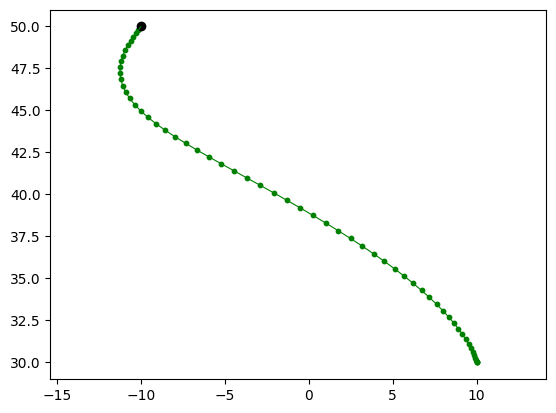

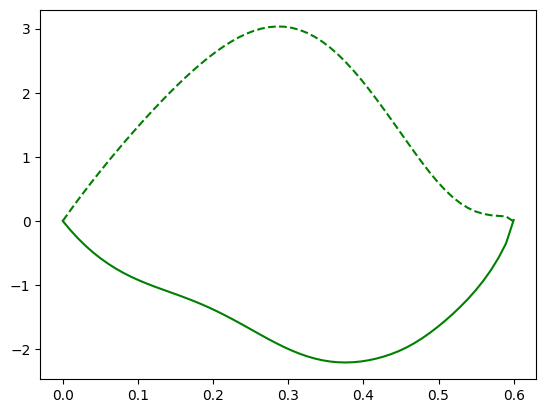

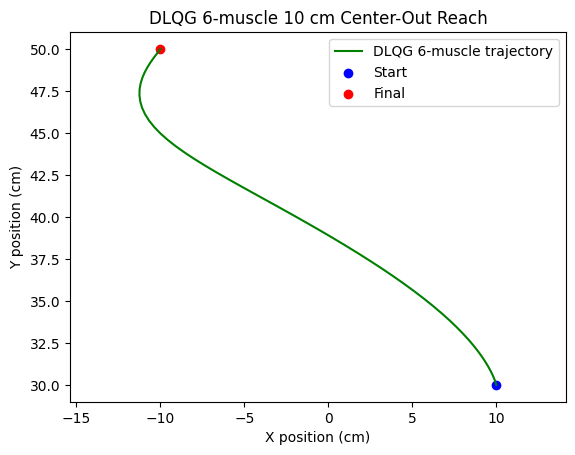

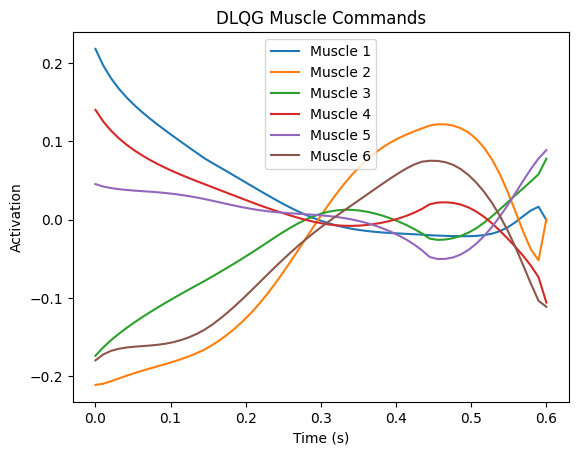

In [21]:

Duration = 0.6          # 600 ms movement
Num_iter = 60           # 10 ms discretization
Delay = 0               # No sensory delay
motor_variance = 1e-3   # Noise level

# Start at (0,45) degrees → Cartesian approx around 20 cm radius
starting_point = [10, 30]

# Move outward by 10 cm (your model uses joint angles → convert externally if needed)
target_point = [-10, 50]


# -----------------------------
# Run DLQG 6-muscle controller
# -----------------------------
X, Y, U, x_nonlin = DLQG_6Muscles(
    Duration=Duration,
    starting_point=starting_point,
    targets=target_point,
    Num_iter=Num_iter,
    Delay=Delay,
    motornoise_variance=motor_variance,
    FF=False,        # No feedforward term
    ClassicLQG=False # Use the DLQG variant
)


# -----------------------------
# Plot endpoint trajectory
# -----------------------------
plt.figure()
plt.plot(X, Y, '-g', label='DLQG 6-muscle trajectory')
plt.scatter([X[0]], [Y[0]], color='blue', label='Start')
plt.scatter([X[-1]], [Y[-1]], color='red', label='Final')
plt.axis('equal')
plt.xlabel("X position (cm)")
plt.ylabel("Y position (cm)")
plt.title("DLQG 6-muscle 10 cm Center-Out Reach")
plt.legend()
plt.show()


# -----------------------------
# Plot muscle activations
# -----------------------------
plt.figure()
time = np.linspace(0, Duration, len(U))
for i in range(6):
    plt.plot(time, U[:, i], label=f"Muscle {i+1}")

plt.xlabel("Time (s)")
plt.ylabel("Activation")
plt.title("DLQG Muscle Commands")
plt.legend()
plt.show()

In [49]:
import numpy as np
from math import *

I1 = 0.025
I2 = 0.045
m1 = 1.4
m2 = 1
l1 = 0.3
l2 = 0.33
s1 = 0.11
s2 = 0.16
K = 1 / 0.06
tau = 0.06


a1 = I1 + I2 + m2 * l1 * l1
a2 = m2 * l1 * s2
a3 = I2

Viscous = np.array([[0.05, 0.025], [0.025, 0.05]])


def compute_angles_from_cartesian(x, y, l1=30, l2=33):
    """
    Computes joint angles in radians based on cartesian coordinates.

    Parameters:
        x (float): x-coordinate of the end effector.
        y (float): y-coordinate of the end effector.
        l1 (float): Length of the first link.
        l2 (float): Length of the second link.

    Returns:
        angles (float): Computed angle in radians.
    """
    r_squared = x**2 + y**2

    shoulder_angle = np.arctan2(y, x) - np.arccos(
        (r_squared + l1**2 - l2**2) / (2 * l1 * np.sqrt(r_squared))
    )

    elbow_angle = np.pi - np.arccos((l1**2 + l2**2 - r_squared) / (2 * l1 * l2))
    return shoulder_angle, elbow_angle


def compute_forcefield(theta, omega, acc, coefficient):
    """
    Compute the joint angles acceleration resulting from a lateral
    velocity-dependent forcefield.

    Args:
        theta : current joint angles
        omega : current joint angular velocities
        acc : current joint angular accelerations
        coefficient : Multiplier coefficient on the force field such that yddot = 13 * coeff * xdot

    """
    t0, t1 = theta
    o0, o1 = omega
    sin_t0, cos_t0 = np.sin(t0), np.cos(t0)
    sin_t01, cos_t01 = np.sin(t0 + t1), np.cos(t0 + t1)

    fe = -33 * sin_t01
    fs = fe - 30 * sin_t0
    ge = 33 * cos_t01
    gs = ge + 30 * cos_t0

    fse = -33 * cos_t01
    gse = -33 * sin_t01
    fee = fse
    fss = fse - 30 * cos_t0
    gee = fe
    gss = fs

    xddot = (
        13 * (gs * o0 + ge * o1) * coefficient
        + fss * o0 * o0
        + 2 * fse * o0 * o1
        + fee * o1 * o1
        + fs * acc[0]
        + fe * acc[1]
    )
    yddot = (
        gss * o0 * o0 + 2 * gse * o0 * o1 + gee * o1 * o1 + gs * acc[0] + ge * acc[1]
    )

    gamma = xddot - fss * o0 * o0 - 2 * fse * o0 * o1 - fee * o1 * o1
    nu = yddot - gss * o0 * o0 - 2 * gse * o0 * o1 - gee * o1 * o1
    F1 = (fe * nu - ge * gamma) / (fe * gs - ge * fs) - acc[0]
    F2 = (gs * gamma - fs * nu) / (gs * fe - ge * fs) - acc[1]
    return np.array([F1, F2])


def get_linearized_dynamics(x, u):
    """
    Parameters :
        - x : the state of the system
        - alpha : the body tilt

    return :
        The Jacobian Matrix of the dynamic of the system around the state x
    """

    theta1, theta2, dtheta1, dtheta2 = x[:4]
    C = np.array(
        [
            -dtheta2 * (2 * dtheta1 + dtheta2) * a2 * np.sin(theta2),
            dtheta1**2 * a2 * np.sin(theta2),
        ]
    )

    dCdte = np.array(
        [
            -dtheta2 * (2 * dtheta1 + dtheta2) * a2 * np.cos(theta2),
            dtheta1**2 * a2 * np.cos(theta2),
        ]
    )
    dCdos = np.array(
        [-dtheta2 * 2 * a2 * np.sin(theta2), 2 * dtheta1 * a2 * np.sin(theta2)]
    )
    dCdoe = np.array([(-2 * dtheta1 - 2 * dtheta2) * a2 * np.sin(theta2), 0])

    M = np.array(
        [
            [a1 + 2 * a2 * np.cos(theta2), a3 + a2 * np.cos(theta2)],
            [a3 + a2 * np.cos(theta2), a3],
        ]
    )

    Minv = np.linalg.inv(M)

    dM = np.array(
        [[-2 * a2 * np.sin(theta2), -a2 * np.sin(theta2)], [-a2 * np.sin(theta2), 0]]
    )

    A = np.array([[2, -2, 0, 0, 1.5, -2], [0, 0, 2, -2, 2, -1.5]])

    l0 = np.array([7.32, 3.26, 6.4, 4.26, 5.95, 4.04])
    theta0 = np.array(
        [
            [
                2 * pi / 360 * 15,
                2 * pi / 360 * 4.88,
                0,
                0,
                2 * pi / 360 * 4.5,
                2 * pi / 360 * 2.12,
            ],
            [
                0,
                0,
                2 * pi / 360 * 80.86,
                2 * pi / 360 * 109.32,
                2 * pi / 360 * 92.96,
                2 * pi / 360 * 91.52,
            ],
        ]
    )
    l = 1 + A[0] * (theta0[0] - x[0]) / l0 + A[1] * (theta0[1] - x[1]) / l0
    dldts = -A[0] / l0
    dldte = -A[1] / l0

    v = A[0] * (-x[2]) / l0 + A[1] * (-x[3]) / l0
    dvdos = -A[0] / l0
    dvdoe = -A[1] / l0
    fl = np.exp(np.abs((l**1.55 - 1) / 0.81))

    dfldl = (
        np.exp(np.abs((l**1.55 - 1) / 0.81))
        * np.sign((l**1.55 - 1) / 0.81)
        * (1.55 * l**0.55 / 0.81)
    )
    fv = np.where(
        v <= 0,
        (-7.39 - v) / (-7.39 + (-3.21 + 4.17) * v),
        (0.62 - (-3.12 + 4.21 * l - 2.67 * l**2) * v) / (0.62 + v),
    )
    dfvdl = np.where(v <= 0, 0, v * (-4.21 + 5.34 * l) / (0.62 + v))

    dfvdv = np.where(
        v <= 0,
        7.39 * (1 + 0.96) / (-7.39 + 0.96 * v) ** 2,
        -0.62 * (-3.12 + 4.21 * l - 2.67 * l**2 + 1) / (0.62 + v) ** 2,
    )

    dfldts = dfldl * dldts
    dfldte = dfldl * dldte
    dfvdts = dfvdl * dldts
    dfvdte = dfvdl * dldte
    dfvdos = dfvdv * dvdos
    dfvdoe = dfvdv * dvdoe

    # Compute acceleration dependencies
    dtheta = np.array([dtheta1, dtheta2])

    d_accel_theta1 = Minv @ (A @ (u * (dfldts * fv + fl * dfvdts)))
    d_accel_dtheta1 = Minv @ (
        A @ (u * dfvdos * fl) - dCdos - Viscous @ np.array([1, 0])
    )
    d_accel_theta2 = -Minv @ (
        dM @ Minv @ (A @ (u * fl * fv) - C - Viscous @ dtheta)
    ) + Minv @ (A @ (u * (dfldte * fv + fl * dfvdte)) - dCdte)
    d_accel_dtheta2 = Minv @ (
        A @ (u * dfvdoe * fl) - dCdoe - Viscous @ np.array([0, 1])
    )

    # Construct the Jacobian matrix
    A = np.zeros((4, 4))

    A[0, 2] = 1
    A[1, 3] = 1

    # Acceleration contributions
    A[2, 0] = d_accel_theta1[0]
    A[2, 2] = d_accel_dtheta1[0]
    A[2, 1] = d_accel_theta2[0]
    A[2, 3] = d_accel_dtheta2[0]

    A[3, 0] = d_accel_theta1[1]
    A[3, 2] = d_accel_dtheta1[1]
    A[3, 1] = d_accel_theta2[1]
    A[3, 3] = d_accel_dtheta2[1]

    return A


def f(x, u):
    C = np.array(
        [-x[3] * (2 * x[2] + x[3]) * a2 * np.sin(x[1]), x[2] ** 2 * a2 * np.sin(x[1])]
    )

    Denominator = a3 * (a1 - a3) - a2**2 * np.cos(x[1]) ** 2
    Minv = np.array(
        [
            [a3 / Denominator, (-a2 * np.cos(x[1]) - a3) / Denominator],
            [
                (-a2 * np.cos(x[1]) - a3) / Denominator,
                (2 * a2 * np.cos(x[1]) + a1) / Denominator,
            ],
        ]
    )
    A = np.array([[2, -2, 0, 0, 1.5, -2], [0, 0, 2, -2, 2, -1.5]])

    l0 = np.array([7.32, 3.26, 6.4, 4.26, 5.95, 4.04])
    theta0 = np.array(
        [
            [
                2 * pi / 360 * 15,
                2 * pi / 360 * 4.88,
                0,
                0,
                2 * pi / 360 * 4.5,
                2 * pi / 360 * 2.12,
            ],
            [
                0,
                0,
                2 * pi / 360 * 80.86,
                2 * pi / 360 * 109.32,
                2 * pi / 360 * 92.96,
                2 * pi / 360 * 91.52,
            ],
        ]
    )
    l = 1 + A[0] * (theta0[0] - x[0]) / l0 + A[1] * (theta0[1] - x[1]) / l0
    v = A[0] * (-x[2]) / l0 + A[1] * (-x[3]) / l0

    fl = np.exp(np.abs((l**1.55 - 1) / 0.81))

    ff_v = np.where(
        v <= 0,
        (-7.39 - v) / (-7.39 + (-3.21 + 4.17) * v),
        (0.62 - (-3.12 + 4.21 * l - 2.67 * l**2) * v) / (0.62 + v),
    )
    theta = Minv @ (A @ (u * fl * ff_v) - Viscous @ x[2:4] - C)

    return np.array([[x[2], x[3], theta[0], theta[1]]])


def fx(x, u):
    return get_linearized_dynamics(x, u)


def fu(x, u):
    Denominator = a3 * (a1 - a3) - a2**2 * np.cos(x[1]) ** 2
    Minv = np.array(
        [
            [a3 / Denominator, (-a2 * np.cos(x[1]) - a3) / Denominator],
            [
                (-a2 * np.cos(x[1]) - a3) / Denominator,
                (2 * a2 * np.cos(x[1]) + a1) / Denominator,
            ],
        ]
    )
    A = np.array([[2, -2, 0, 0, 1.5, -2], [0, 0, 2, -2, 2, -1.5]])

    l0 = np.array([7.32, 3.26, 6.4, 4.26, 5.95, 4.04])
    theta0 = np.array(
        [
            [
                2 * pi / 360 * 15,
                2 * pi / 360 * 4.88,
                0,
                0,
                2 * pi / 360 * 4.5,
                2 * pi / 360 * 2.12,
            ],
            [
                0,
                0,
                2 * pi / 360 * 80.86,
                2 * pi / 360 * 109.32,
                2 * pi / 360 * 92.96,
                2 * pi / 360 * 91.52,
            ],
        ]
    )
    l = 1 + A[0] * (theta0[0] - x[0]) / l0 + A[1] * (theta0[1] - x[1]) / l0
    v = A[0] * (-x[2]) / l0 + A[1] * (-x[3]) / l0
    # Equation (6): fl(l)
    fl = np.exp(np.abs((l**1.55 - 1) / 0.81))
    # Equation (7): ff_v(l, v)
    fv = np.where(
        v <= 0,
        (-7.39 - v) / (-7.39 + (-3.21 + 4.17) * v),
        (0.62 - (-3.12 + 4.21 * l - 2.67 * l**2) * v) / (0.62 + v),
    )
    sol = np.zeros((4, 6))
    for i in range(6):
        du = np.zeros(6)
        du[i] = 1
        sol[2:, i] = Minv @ (A @ (du * fl * fv))
    return sol


def l(x, u, r1, xtarg=0, w1=0, w2=0):
    return r1 * np.sum(u**2) / 2 + (I1*x[2]**2+I2*x[3]**2)/2


def lx(x, u, xtarg=0, w1=0, w2=0):
    return np.array([0,0, I1*x[2], I2*x[3]])


def lu(x, u, r1):
    return r1 * u


def lxx(w1=0, w2=0):
    arr = np.zeros((4, 4))
    arr[2,2]    = I1
    arr[3,3]    = I2
    return arr


def luu(x, u, r1):
    return np.diag(np.ones(len(u))) * r1


def h(x, w1, w2, xtarg):
    return w1 / 2 * ((x[0] - xtarg[0]) ** 2 + (x[1] - xtarg[1]) ** 2) + w2 / 2 * (
        x[2] ** 2 + x[3] ** 2
    )


def hx(x, w1, w2, xtarg):
    return np.array(
        [w1 * (x[0] - xtarg[0]), w1 * (x[1] - xtarg[1]), w2 * x[2], w2 * x[3]]
    )


def hxx(x, w1, w2):
    return np.diag([w1, w1, w2, w2])


def Kalman(Omega_measure, Omega_sens, A, sigma, H):
    K = A @ sigma @ H.T @ np.linalg.inv(H @ sigma @ H.T + Omega_measure)
    sigma = Omega_sens + (A - K @ H) @ sigma @ A.T
    return K, sigma


def step1(x0, u, Duration):
    K = np.shape(u)[0] + 1
    dt = Duration / (K)
    newx = np.zeros((K, len(x0)))
    newx[0] = np.copy(x0)

    for i in range(K - 1):
        newx[i + 1] = newx[i] + dt * f(newx[i], u[i])

    return newx


def step2(x, u, Duration, w1, w2, r1, xtarg):
    K = np.shape(u)[0] + 1
    dt = Duration / K
    n, m = len(x[0]), len(u[0])

    A, B = np.zeros((K - 1, n, n)), np.zeros((K - 1, n, m))
    q, qbold = np.zeros(K), np.zeros((K, n))
    r, Q, R = np.zeros((K - 1, m)), np.zeros((K, n, n)), np.zeros((K - 1, m, m))

    for i in range(K - 1):
        A[i] = np.identity(n) + dt * fx(x[i], u[i])
        B[i] = dt * fu(x[i], u[i])
        q[i] = dt * l(x[i], u[i], r1, xtarg, w1, w2)
        qbold[i] = dt * lx(x[i], u[i], xtarg, w1, w2)
        r[i] = dt * lu(x[i], u[i], r1)
        Q[i] = dt * lxx(w1, w2)
        R[i] = dt * luu(x[i], u[i], r1)

    q[-1], qbold[-1], Q[-1] = (
        h(x[-1], w1, w2, xtarg),
        hx(x[-1], w1, w2, xtarg),
        hxx(x[-1], w1, w2),
    )
    return A, B, q, qbold, r, Q, R


def step3(A, B, C, cbold, q, qbold, r, Q, R, eps):
    K = A.shape[0] + 1
    n, m = np.shape(B[0])
    S = np.zeros((K, n, n))
    s = np.zeros(K)
    sbold = np.zeros((K, n))
    l = np.zeros((K - 1, m))
    L = np.zeros((K - 1, m, n))

    S[-1] = Q[-1]
    s[-1] = q[-1]
    sbold[-1] = qbold[-1]

    for k in np.arange(K - 2, -1, -1):
        temp1, temp2, temp3 = 0, 0, 0

        for i in range(m):
            temp1 += C[k, i, :, :].T @ S[k + 1] @ cbold[k, i, :]
            temp2 += C[k, i, :, :].T @ S[k + 1] @ C[k, i, :, :]
            temp3 += cbold[k, i, :].T @ S[k + 1] @ cbold[k, i, :]

        gbold = r[k] + B[k].T @ sbold[k + 1] + temp1
        G = B[k].T @ S[k + 1] @ A[k]
        H = R[k] + B[k].T @ S[k + 1] @ B[k] + temp2

        eigenvalues, eigenvectors = np.linalg.eig(H)
        V = np.diag(eigenvalues)

        for i in range(V.shape[0]):
            if V[i, i] < (eps):
                print("H matrix poorly defined")
                V[i, i] = eps
            V[i, i] = 1 / V[i, i]
        Hinv = eigenvectors @ V @ np.linalg.inv(eigenvectors)

        S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
        sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
        s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold

        l[k] = -Hinv @ gbold
        L[k] = -Hinv @ G

    return l, L


def step4(l, L, K, A, B):
    m, n = L[0].shape
    x = np.zeros(n)
    u_incr = np.zeros((K - 1, m))

    for k in range(K - 1):
        u_incr[k] = l[k] + L[k] @ x
        x = A[k] @ x + B[k] @ u_incr[k]

    return u_incr


def step5(
    x0,
    l,
    L,
    Duration,
    Noise,
    A,
    B,
    Num_steps,
    bestu,
    kdelay,
    motornoise_variance,
    FF,
    ff_power,
):
    dt = Duration / (Num_steps)
    Num_Var = len(x0)

    x0 = np.tile(x0, kdelay + 1)
    xref = np.zeros((Num_steps, Num_Var * (kdelay + 1)))
    xref[0] = np.copy(x0)
    newx = np.zeros((Num_steps, Num_Var * (kdelay + 1)))
    newx[0] = np.copy(x0)
    xhat = np.zeros((Num_steps, Num_Var * (kdelay + 1)))

    H = np.zeros((Num_Var, (kdelay + 1) * Num_Var))
    H[:, (kdelay) * Num_Var :] = np.identity(Num_Var)

    sigma = np.zeros((Num_Var * (kdelay + 1), Num_Var * (kdelay + 1)))
    Omega_measure = np.diag(np.ones(4)) * 1e-4
    F = 0
    for i in range(Num_steps - 1):
        if i != 0:
            acc = (f(newx[i, :Num_Var], u)[:, 2:4] + F).reshape(2)
        else:
            acc = np.zeros(2)
        F = (
            compute_forcefield(newx[i, 0:2], newx[i, 2:4], acc, ff_power)
            if FF == True
            else np.array([0, 0])
        )
        Extended_A = np.zeros(((kdelay + 1) * Num_Var, (kdelay + 1) * Num_Var))
        Extended_A[:Num_Var, :Num_Var] = A[i]
        Extended_A[Num_Var:, :-Num_Var] = np.identity((kdelay) * Num_Var)
        Extended_B = np.zeros(((kdelay + 1) * Num_Var, 6))
        Extended_B[:Num_Var] = B[i]

        deltau = l[i] + L[i] @ xhat[i, :Num_Var]
        u = bestu[i] + deltau

        Omega_sens = np.zeros((len(x0), len(x0)))
        for idx in [2, 3]:
            Omega_sens[idx, idx] = motornoise_variance
        K, sigma = Kalman(Omega_measure, Omega_sens, Extended_A, sigma, H)

        passed_newx = np.copy(newx[i, :-Num_Var])
        newx[i + 1, :Num_Var] = newx[i, :Num_Var] + dt * f(newx[i, :Num_Var], u)
        newx[i + 1, 2:4] += dt * F
        newx[i + 1, Num_Var:] = passed_newx

        passed_xref = np.copy(xref[i, :-Num_Var])
        xref[i + 1, :Num_Var] = xref[i, :Num_Var] + dt * f(xref[i, :Num_Var], bestu[i])
        xref[i + 1, Num_Var:] = passed_xref

        if Noise:
            newx[i + 1, 2:4] += np.random.normal(0, np.sqrt(motornoise_variance), 2)

        y = H @ (newx[i] - xref[i])
        if Noise:
            y += np.random.normal(0, 1e-2, len(y))

        xhat[i + 1] = (Extended_A @ xhat[i] + Extended_B @ deltau) + K @ (
            y - H @ xhat[i]
        )
    return newx[:, :Num_Var]


def simulate_ILQG(
    Duration=0.5,
    w1=1e3,
    w2=1,
    r1=1e-4,
    targets=[0, 50],
    start=[0, 30],
    K=120,
    Noise=False,
    delay=0,
    eps=1e-4,
    motornoise_variance=1e-3,
    print_iterations=True,
    FF=False,
    ff_power=0.3,
):
    """
    Parameters :
        - Duration : Movement Duration in sec
        - w1,w2,r1 : Weight of the costs function associated to distance penalty  to the target, end velocity, and motor costs respectively
        - targets : Position of the target in cartesian coordinates
        - k : Number of iterations
        - start : Starting position of the hand
        - plot : Boolean, True ==> plotting enabled
        - Noise : Boolean, True ==> Noise Activated in the simulation
        - Delay : Sensory Delay in sec
        - motornoise_variance : Variance of the motor noise
        - alpha : Body Tilt in radiant

    return :
        - X,Y : Cartesian coordinates of the hand trajectory
        - u : Input command
        - x : Vector state of the trajectory
    """

    obj1, obj2 = compute_angles_from_cartesian(targets[0], targets[1])
    st1, st2 = compute_angles_from_cartesian(start[0], start[1])

    x0 = np.array([st1, st2, 0, 0])
    m, n = 6, 4
    u = np.zeros((K - 1, m))
    dt = Duration / K
    kdelay = int(delay / dt)

    cbold = np.zeros((K - 1, m, n))
    C = np.zeros((K - 1, m, n, m))
    for i in range(K - 1):
        for j in range(2):
            cbold[i, j, 2 + j] = sqrt(motornoise_variance)

    u_incr = np.ones(u.shape) * np.inf

    for iterate in range(300):
        x = step1(
            x0, u, Duration
        )  # Forward step computing the sequence of state trajectory given a sequence of input u
        X = np.cos(x[:, 0] + x[:, 1]) * 33 + np.cos(x[:, 0]) * 30
        Y = np.sin(x[:, 0] + x[:, 1]) * 33 + np.sin(x[:, 0]) * 30

        if (
            np.max(np.abs(u_incr)) < 1e-14
        ):  # If the trajectory improvement is small enough, stop the iteration and perform a full simulation with feedback and potential noise
            x = step5(
                x0,
                l,
                L,
                Duration,
                Noise,
                A,
                B,
                K,
                u - u_incr,
                kdelay,
                motornoise_variance,
                FF,
                ff_power,
            )
            X = np.cos(x[:, 0] + x[:, 1]) * 33 + np.cos(x[:, 0]) * 30
            Y = np.sin(x[:, 0] + x[:, 1]) * 33 + np.sin(x[:, 0]) * 30
            if print_iterations:
                print("Solution found at iteration ", iterate)
            break

        A, B, q, qbold, r, Q, R = step2(
            x, u, Duration, w1, w2, r1, np.array([obj1, obj2])
        )  # Compute the Linearizations of the dynamic
        l, L = step3(
            A, B, C, cbold, q, qbold, r, Q, R, eps
        )  # Compute the control gains improvement (feedforward and feedback)
        u_incr = step4(l, L, K, A, B)  # Compute the command sequence improvement
        u += u_incr  # Improves the command sequence
    return X, Y, x, u


C:\Users\thyriona\AppData\Local\Temp\ipykernel_8640\2531225246.py:454: ComplexWarning: Casting complex values to real discards the imaginary part
  S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
C:\Users\thyriona\AppData\Local\Temp\ipykernel_8640\2531225246.py:455: ComplexWarning: Casting complex values to real discards the imaginary part
  sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_8640\2531225246.py:456: ComplexWarning: Casting complex values to real discards the imaginary part
  s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_8640\2531225246.py:458: ComplexWarning: Casting complex values to real discards the imaginary part
  l[k] = -Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_8640\2531225246.py:459: ComplexWarning: Casting complex values to real discards the imaginary part
  L[k] = -Hinv @ G


Solution found at iteration  28


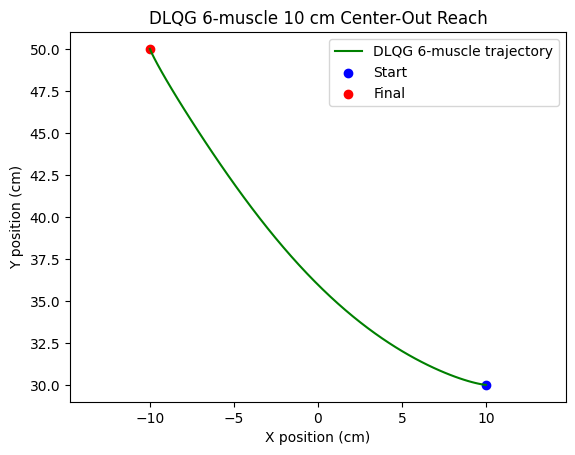

In [38]:

Duration = 0.6          # 600 ms movement
Num_iter = 60           # 10 ms discretization
Delay = 0               # No sensory delay
motor_variance = 1e-3   # Noise level

# Start at (0,45) degrees → Cartesian approx around 20 cm radius
starting_point = [10, 30]

# Move outward by 10 cm (your model uses joint angles → convert externally if needed)
target_point = [-10, 50]


# -----------------------------
# Run DLQG 6-muscle controller
# -----------------------------
X, Y, U, x_nonlin = simulate_ILQG(
    w1 = 100,w2 = .05,r1 = .1,
    Duration=Duration,
    start=starting_point,
    targets=target_point,
    K=Num_iter,
    delay=Delay,
    motornoise_variance=motor_variance,
    FF=False,        # No feedforward term# Use the DLQG variant
)


# -----------------------------
# Plot endpoint trajectory
# -----------------------------
plt.figure()
plt.plot(X, Y, '-g', label='DLQG 6-muscle trajectory')
plt.scatter([X[0]], [Y[0]], color='blue', label='Start')
plt.scatter([X[-1]], [Y[-1]], color='red', label='Final')
plt.axis('equal')
plt.xlabel("X position (cm)")
plt.ylabel("Y position (cm)")
plt.title("DLQG 6-muscle 10 cm Center-Out Reach")
plt.legend()
plt.show()


plt.show()

C:\Users\thyriona\AppData\Local\Temp\ipykernel_8640\3332658145.py:454: ComplexWarning: Casting complex values to real discards the imaginary part
  S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
C:\Users\thyriona\AppData\Local\Temp\ipykernel_8640\3332658145.py:455: ComplexWarning: Casting complex values to real discards the imaginary part
  sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_8640\3332658145.py:456: ComplexWarning: Casting complex values to real discards the imaginary part
  s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_8640\3332658145.py:458: ComplexWarning: Casting complex values to real discards the imaginary part
  l[k] = -Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_8640\3332658145.py:459: ComplexWarning: Casting complex values to real discards the imaginary part
  L[k] = -Hinv @ G


Solution found at iteration  21


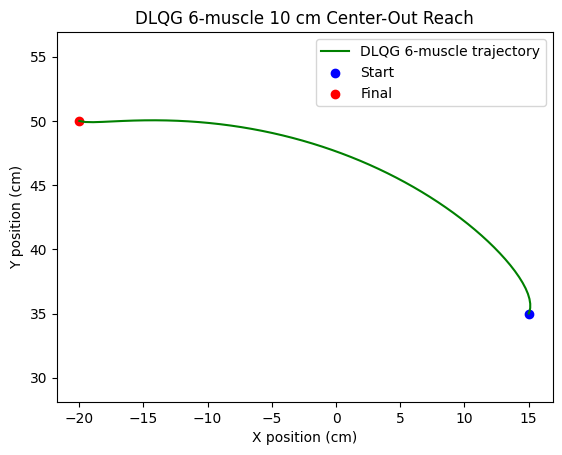

In [50]:

Duration = 0.6          # 600 ms movement
Num_iter = 60           # 10 ms discretization
Delay = 0               # No sensory delay
motor_variance = 1e-3   # Noise level

# Start at (0,45) degrees → Cartesian approx around 20 cm radius
starting_point = [15, 35]

# Move outward by 10 cm (your model uses joint angles → convert externally if needed)
target_point = [-20, 50]


# -----------------------------
# Run DLQG 6-muscle controller
# -----------------------------
X, Y, U, x_nonlin = simulate_ILQG(
    w1 = 100,w2 = .05,r1 = .1,
    Duration=Duration,
    start=starting_point,
    targets=target_point,
    K=Num_iter,
    delay=Delay,
    motornoise_variance=motor_variance,
    FF=False,        # No feedforward term# Use the DLQG variant
)


# -----------------------------
# Plot endpoint trajectory
# -----------------------------
plt.figure()
plt.plot(X, Y, '-g', label='DLQG 6-muscle trajectory')
plt.scatter([X[0]], [Y[0]], color='blue', label='Start')
plt.scatter([X[-1]], [Y[-1]], color='red', label='Final')
plt.axis('equal')
plt.xlabel("X position (cm)")
plt.ylabel("Y position (cm)")
plt.title("DLQG 6-muscle 10 cm Center-Out Reach")
plt.legend()
plt.show()


plt.show()